# Delta-Band Trigger -- Ensemble Sandbox

Apples-to-apples comparison against the production result (Sharpe 1.02, MaxDD -20.5%).
Uses the same `simulate_ensemble` logic: CBA selection (cheapest of TSLA vs TSLL call),
50% stop-loss, frictionless costs. The only addition is a **delta-drift trigger**: if
`|current_delta - entry_delta| > delta_band`, roll early into a fresh contract.

Fixed config: **10% OTM / target_dte=90 / roll_dte=5 / stop_loss=0.5 / frictionless**.  
Sweep: `delta_band` in [None (baseline), 0.10, 0.15, 0.20, 0.25, 0.30].  
Full period only. Results table + equity/drawdown plot.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls, load_tsll_calls
from options_selection import select_contract, bs_delta
from metrics import summarize
# Import CBA helpers so we don't duplicate them
from cba_backtest import _position_cost, _best_alternative

%matplotlib inline

# ── spot ──────────────────────────────────────────────────────────────────────
tsll_df   = load_tsll()
r_tsll    = tsll_df.set_index("Date")["Close"].pct_change().dropna()
returns   = r_tsll.rename("TSLL").to_frame()

tsla_spot = load_tsla_underlying().set_index("Date")["Close"].reindex(returns.index).ffill()
tsll_spot = tsll_df.set_index("Date")["Close"].reindex(returns.index).ffill()

# ── options ───────────────────────────────────────────────────────────────────
tsla_calls = load_tsla_calls()
tsll_calls = load_tsll_calls()

tsla_lut     = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsll_lut     = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsla_vol_lut = tsla_calls.set_index(["raw_id", "date"])["px_volume"].to_dict()
tsll_vol_lut = tsll_calls.set_index(["raw_id", "date"])["px_volume"].to_dict()

# ── realised vol ──────────────────────────────────────────────────────────────
tsla_sigma = (tsla_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()
tsll_sigma = (tsll_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()

print(f"{len(returns):,} trading days  {returns.index.min().date()} -> {returns.index.max().date()}")
print("Data loaded.")

962 trading days  2022-08-10 -> 2026-06-10
Data loaded.


In [2]:
# ── fixed config (matches production Pareto-optimal) ──────────────────────────
BUCKET      = "10% OTM"
TARGET_DTE  = 90
MAX_DTE     = 110
ROLL_DTE    = 5
STOP_LOSS   = 0.5     # roll early if unrealized loss > 50% of entry premium
TSLL_LEVER  = 2.0
R_RF        = 0.05
BUCKETS_ALL = ["ATM", "10% OTM", "20% OTM"]   # stop-loss search space

DELTA_BANDS = [None, 0.10, 0.15, 0.20, 0.25, 0.30]
# None = static baseline (calendar + stop-loss only) -- should reproduce production result

print(f"bucket={BUCKET}  target_dte={TARGET_DTE}  roll_dte={ROLL_DTE}  stop_loss={STOP_LOSS}  frictionless")
print(f"delta_bands: {DELTA_BANDS}")

bucket=10% OTM  target_dte=90  roll_dte=5  stop_loss=0.5  frictionless
delta_bands: [None, 0.1, 0.15, 0.2, 0.25, 0.3]


In [3]:
def _live_delta(pos, d):
    """Recompute BS delta of the held call at today's market conditions."""
    spot_s = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
    sig_s  = tsla_sigma if pos["underlying"] == "tsla" else tsll_sigma
    S      = float(spot_s.loc[d])
    sigma  = float(sig_s.loc[d]) if d in sig_s.index else 0.5
    T      = max((pos["expiry"] - d).days / 365.25, 1 / 365.25)
    return bs_delta(S, pos["strike"], T, R_RF, sigma)


def simulate_delta_band_ensemble(returns, delta_band=None):
    """
    Replicates simulate_ensemble (CBA selection + 50% stop-loss, frictionless)
    and adds one new trigger: delta-drift.

    Roll when ANY of:
      (a) held DTE < ROLL_DTE            -- calendar
      (b) unrealized loss > STOP_LOSS    -- stop-loss
      (c) |current_delta-entry_delta| > delta_band  -- drift (if set)

    On every roll, enter whichever of (TSLA call, TSLL call) costs less
    delta-neutral -- same CBA logic as production.

    delta_band=None disables the drift trigger (pure baseline).
    """
    cum_tsll    = (1 + returns["TSLL"]).cumprod()
    base_equity = 2.0 - cum_tsll

    equity      = pd.Series(index=returns.index, dtype=float)
    position    = None   # adds "underlying", "entry_delta" vs plain simulate
    option_pnl  = 0.0
    n_early     = {"stop_loss": 0, "delta_drift": 0}
    n_unhedged  = 0

    def mtm(pos, d):
        lkp  = tsla_lut if pos["underlying"] == "tsla" else tsll_lut
        spot = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        if d > pos["expiry"]:
            return max(float(spot.loc[d]) - pos["strike"], 0.0)
        px = lkp.get((pos["raw_id"], d))
        return float(px) if (px is not None and not pd.isna(px)) else pos["price"]

    def can_exit(pos, d):
        if d > pos["expiry"]:
            return True
        vlkp = tsla_vol_lut if pos["underlying"] == "tsla" else tsll_vol_lut
        v = vlkp.get((pos["raw_id"], d))
        return v is not None and not pd.isna(v) and v > 0

    def open_cheapest(d):
        """CBA: enter whichever of TSLA/TSLL call is cheaper delta-neutral."""
        cum_val = float(cum_tsll.loc[d])
        sig_a   = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
        sig_b   = float(tsll_sigma.loc[d]) if d in tsll_sigma.index else 0.5

        row_a = select_contract(tsla_calls, tsla_spot, d, BUCKET, TARGET_DTE, max_dte=MAX_DTE)
        row_b = select_contract(tsll_calls, tsll_spot, d, BUCKET, TARGET_DTE, max_dte=MAX_DTE)

        cost_a, n_a, entry_a = _position_cost(row_a, tsla_spot.loc[d], sig_a, TSLL_LEVER, cum_val, d)
        cost_b, n_b, entry_b = _position_cost(row_b, tsll_spot.loc[d], sig_b, 1.0,        cum_val, d)

        if cost_a <= cost_b and row_a is not None:
            row, n, entry, ul, delta = row_a, n_a, entry_a, "tsla", bs_delta(
                float(tsla_spot.loc[d]), float(row_a["strike"]),
                (row_a["expiry"]-d).days/365.25, R_RF, sig_a)
        elif row_b is not None:
            row, n, entry, ul, delta = row_b, n_b, entry_b, "tsll", bs_delta(
                float(tsll_spot.loc[d]), float(row_b["strike"]),
                (row_b["expiry"]-d).days/365.25, R_RF, sig_b)
        elif row_a is not None:
            row, n, entry, ul, delta = row_a, n_a, entry_a, "tsla", bs_delta(
                float(tsla_spot.loc[d]), float(row_a["strike"]),
                (row_a["expiry"]-d).days/365.25, R_RF, sig_a)
        else:
            return None

        return {"underlying": ul, "raw_id": row["raw_id"],
                "strike": float(row["strike"]), "expiry": row["expiry"],
                "n": n, "price": entry, "entry_price": entry,
                "entry_delta": delta,         # stored for drift trigger
                "entry_volume": float(row.get("px_volume") or 1.0)}

    for d in returns.index:
        held_dte   = (position["expiry"] - d).days if position is not None else -1
        want_roll  = position is None or held_dte < ROLL_DTE
        exitable   = position is None or can_exit(position, d)

        if want_roll and exitable:
            if position is not None:
                option_pnl += position["n"] * 100 * (mtm(position, d) - position["price"])
            position = open_cheapest(d)
            if position is None:
                n_unhedged += 1

        elif position is not None and exitable:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

            unrealized = (px - position["entry_price"]) / position["entry_price"]
            sl_trigger = unrealized <= -STOP_LOSS

            drift_trigger = False
            if delta_band is not None:
                drift_trigger = abs(_live_delta(position, d) - position["entry_delta"]) > delta_band

            if sl_trigger:
                # Stop-loss: switch only if a cheaper alternative exists (same as production)
                cum_val = float(cum_tsll.loc[d])
                alt = _best_alternative(d, cum_val,
                                        tsla_calls, tsla_spot, tsla_sigma,
                                        tsll_calls, tsll_spot, tsll_sigma,
                                        TARGET_DTE, MAX_DTE, BUCKETS_ALL)
                cur_spot  = tsla_spot if position["underlying"]=="tsla" else tsll_spot
                cur_sigma = float(tsla_sigma.loc[d]) if position["underlying"]=="tsla" else float(tsll_sigma.loc[d])
                cur_lev   = TSLL_LEVER if position["underlying"]=="tsla" else 1.0
                row_cur   = select_contract(
                    tsla_calls if position["underlying"]=="tsla" else tsll_calls,
                    cur_spot, d, BUCKET, TARGET_DTE, max_dte=MAX_DTE)
                cost_cur, _, _ = _position_cost(row_cur, cur_spot.loc[d], cur_sigma, cur_lev, cum_val, d)
                if alt is not None and (cost_cur - alt[0]) > 0:
                    _, ul, bucket_chosen, row, n, entry = alt
                    sig_new = float(tsla_sigma.loc[d]) if ul=="tsla" else float(tsll_sigma.loc[d])
                    delta_new = bs_delta(
                        float((tsla_spot if ul=="tsla" else tsll_spot).loc[d]),
                        float(row["strike"]), (row["expiry"]-d).days/365.25, R_RF, sig_new)
                    position = {"underlying": ul, "raw_id": row["raw_id"],
                                "strike": float(row["strike"]), "expiry": row["expiry"],
                                "n": n, "price": entry, "entry_price": entry,
                                "entry_delta": delta_new,
                                "entry_volume": float(row.get("px_volume") or 1.0)}
                    n_early["stop_loss"] += 1

            elif drift_trigger:
                # Delta-drift: unconditional roll into a fresh cheapest contract
                new_pos = open_cheapest(d)
                if new_pos is not None:
                    position = new_pos
                    n_early["delta_drift"] += 1

        elif position is not None and not exitable:
            # Contract didn't trade today -- hold, retry tomorrow
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        equity.loc[d] = base_equity.loc[d] + option_pnl

    return equity, n_early, n_unhedged

In [4]:
rows   = []
curves = {}

for band in DELTA_BANDS:
    label = "static (baseline)" if band is None else f"delta_band={band:.2f}"
    eq, n_early, n_unhedged = simulate_delta_band_ensemble(returns, delta_band=band)
    eq = eq / eq.iloc[0]
    assert eq.isna().sum() == 0, f"{label}: NaNs in equity"
    curves[label] = eq
    row = summarize(eq, eq.pct_change().dropna(), label)
    row["SL rolls"]      = n_early["stop_loss"]
    row["Delta rolls"]   = n_early["delta_drift"]
    row["Unhedged days"] = n_unhedged
    rows.append(row)
    print(f"{label:30s}  CAGR={row['CAGR']:.1%}  Sharpe={row['Sharpe']:.2f}  "
          f"MaxDD={row['Max DD']:.1%}  SL_rolls={n_early['stop_loss']}  Delta_rolls={n_early['delta_drift']}")

results_df = pd.DataFrame(rows)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", None)
print()
print(results_df[["Strategy", "CAGR", "Ann. Vol", "Sharpe", "Max DD", "Calmar",
                  "SL rolls", "Delta rolls", "Unhedged days"]].to_string(index=False))

static (baseline)               CAGR=14.6%  Sharpe=0.53  MaxDD=-30.9%  SL_rolls=42  Delta_rolls=0


delta_band=0.10                 CAGR=-9.4%  Sharpe=0.02  MaxDD=-44.9%  SL_rolls=34  Delta_rolls=142


delta_band=0.15                 CAGR=-18.2%  Sharpe=-0.42  MaxDD=-60.6%  SL_rolls=49  Delta_rolls=57


delta_band=0.20                 CAGR=-0.3%  Sharpe=0.16  MaxDD=-46.6%  SL_rolls=49  Delta_rolls=31


delta_band=0.25                 CAGR=-23.4%  Sharpe=-0.41  MaxDD=-73.3%  SL_rolls=48  Delta_rolls=20


delta_band=0.30                 CAGR=-8.8%  Sharpe=-0.05  MaxDD=-53.9%  SL_rolls=49  Delta_rolls=16

         Strategy      CAGR  Ann. Vol    Sharpe    Max DD    Calmar  SL rolls  Delta rolls  Unhedged days
static (baseline)  0.145559  0.435603  0.528346 -0.308609  0.471661        42            0              0
  delta_band=0.10 -0.093981  0.485110  0.022329 -0.449350 -0.209149        34          142              2
  delta_band=0.15 -0.182238  0.344115 -0.415145 -0.605820 -0.300812        49           57              2
  delta_band=0.20 -0.003220  0.353743  0.162932 -0.466081 -0.006908        49           31              0
  delta_band=0.25 -0.234395  0.429623 -0.407496 -0.733040 -0.319757        48           20              0
  delta_band=0.30 -0.087837  0.379862 -0.050942 -0.539224 -0.162896        49           16              0


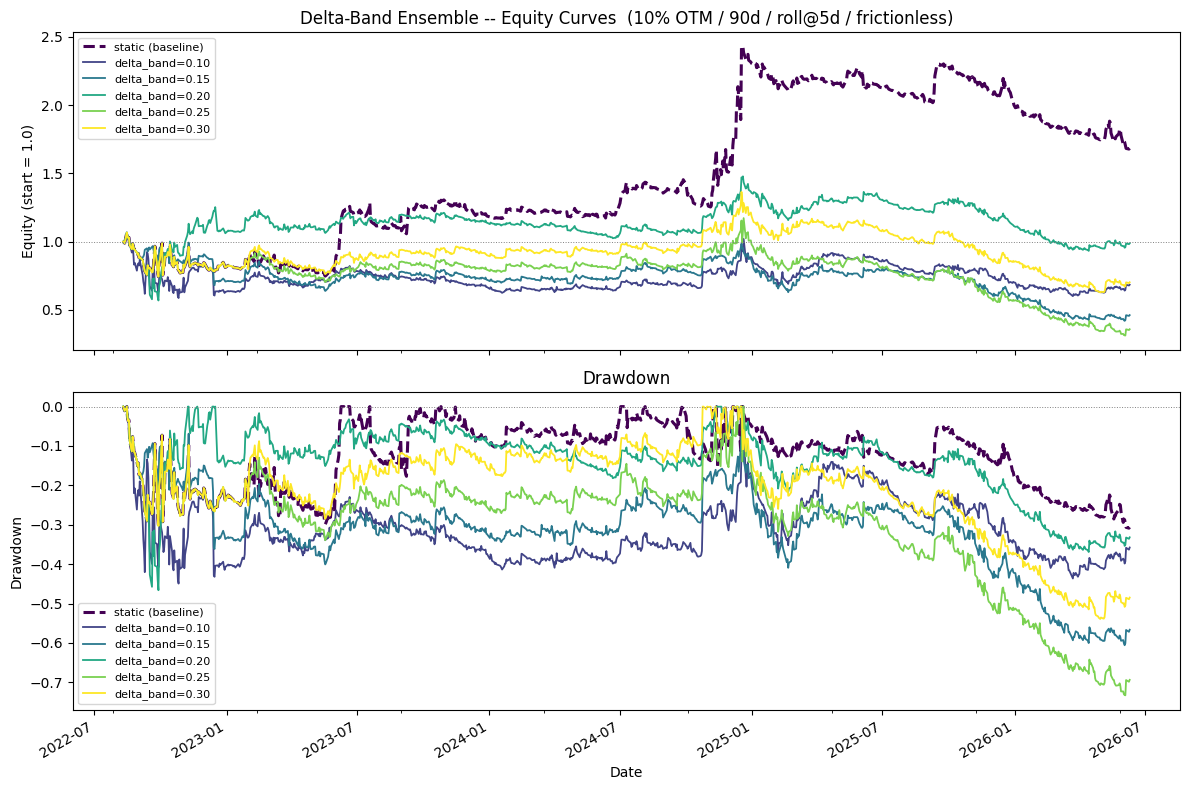

Saved: observations/strategies/sandbox/delta_band_ensemble_comparison.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

colors = cm.viridis([i / max(len(curves)-1, 1) for i in range(len(curves))])
for (label, eq), color in zip(curves.items(), colors):
    lw = 2.2 if "baseline" in label else 1.3
    ls = "--"  if "baseline" in label else "-"
    eq.plot(ax=axes[0], label=label, color=color, linewidth=lw, linestyle=ls)
    (eq / eq.cummax() - 1).plot(ax=axes[1], label=label, color=color, linewidth=lw, linestyle=ls)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=0.7)
axes[0].set_title("Delta-Band Ensemble -- Equity Curves  (10% OTM / 90d / roll@5d / frictionless)")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=8, loc="upper left")

axes[1].axhline(0.0, color="grey", linestyle=":", linewidth=0.7)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=8, loc="lower left")

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "delta_band_ensemble_comparison.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")